In [7]:
import numpy as np
import matplotlib.pyplot as plt


def plot_train_test(X_train, y_train, X_test, y_test):
    sample = 500
    test_len = X_test.shape[0]
    fig = plt.figure(figsize=(15, 5))
    plt.plot(np.arange(0, 500), X_train[-sample:], label="Training data")
    plt.plot(np.arange(0, 500), y_train[-sample:], label="Training ground truth")
    plt.plot(np.arange(500, 500+test_len), X_test, label="Testing data")
    plt.plot(np.arange(500, 500+test_len), y_test, label="Testing ground truth")
    plt.legend()
    plt.show()

def plot_results(y_pred, y_test, sample=500):

    fig = plt.figure(figsize=(15, 7))
    plt.subplot(211)
    plt.plot(np.arange(sample), y_pred[:sample], lw=3, label="ESN prediction")
    plt.plot(np.arange(sample), y_test[:sample], linestyle="--", lw=2, label="True value")
    plt.plot(np.abs(y_test[:sample] - y_pred[:sample]), label="Absolute deviation")

    plt.legend()
    plt.show()

def plot_readout(readout):
    Wout = readout.Wout
    bias = readout.bias
    Wout = np.r_[bias, Wout]

    fig = plt.figure(figsize=(15, 5))

    ax = fig.add_subplot(111)
    ax.grid(axis="y")
    ax.set_ylabel("Coefs. of $W_{out}$")
    ax.set_xlabel("reservoir neurons index")
    ax.bar(np.arange(Wout.size), Wout.ravel()[::-1])

    plt.show()

def plot_lorenz(real_data, pred_data):
    fig = plt.figure(figsize=(15, 7))
    ax = fig.add_subplot(projection='3d')
    ax.plot(real_data[:, 0], real_data[:, 1], real_data[:, 2], label='real_data')
    ax.plot(pred_data[:, 0], pred_data[:, 1], pred_data[:, 2], label='pred_data')
    ax.set_xlabel("X Axis")
    ax.set_ylabel("Y Axis")
    ax.set_zlabel("Z Axis")
    ax.set_title("Orbits of Lorenz System")
    ax.legend()
    plt.show()

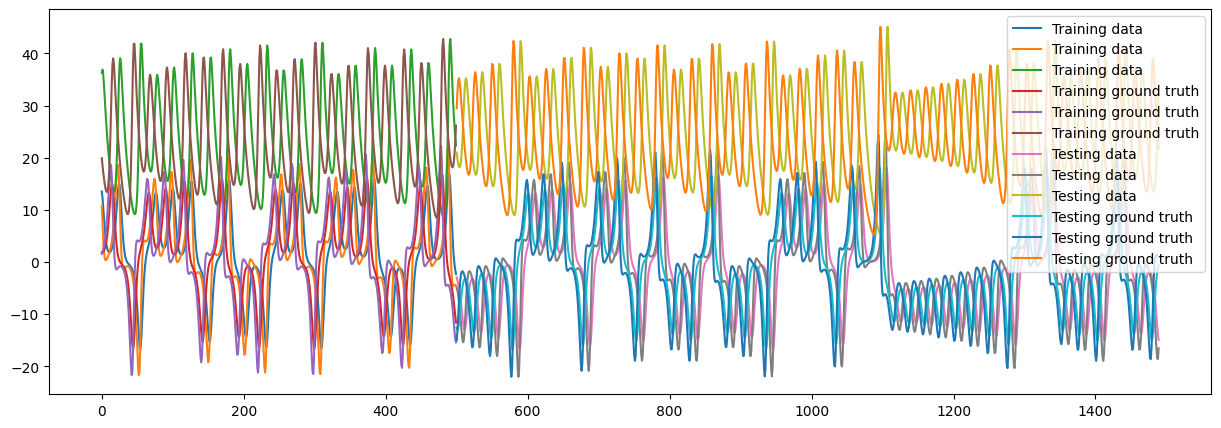

In [3]:
from reservoirpy.datasets import lorenz

time_steps = 3000
X = lorenz(time_steps)

from reservoirpy.datasets import to_forecasting

x, y = to_forecasting(X, forecast=10)
X_train1, y_train1 = x[:2000], y[:2000]
X_test1, y_test1 = x[2000:], y[2000:]

plot_train_test(X_train1, y_train1, X_test1, y_test1)

Running Model-2: 2000it [00:00, 11093.17it/s]?, ?it/s]
Running Model-2: 100%|██████████| 1/1 [00:00<00:00,  5.22it/s]


Fitting node Ridge-2...


Running Model-2: 990it [00:00, 10745.44it/s]          


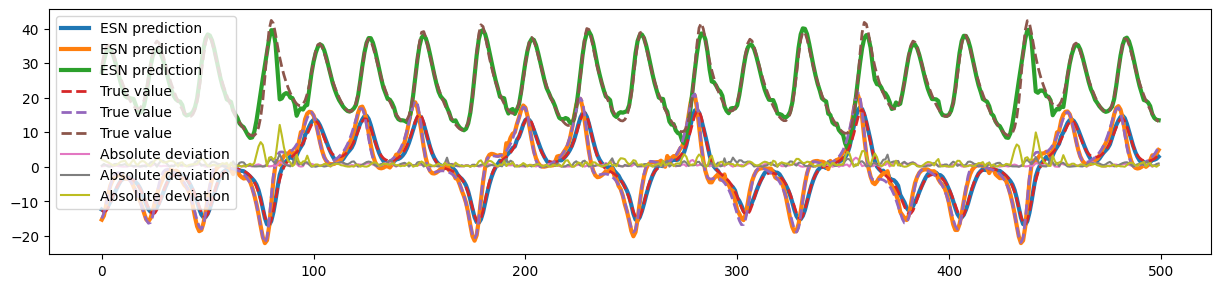

R2 = 0.9947453395280359, RMSE = 0.015780478668159795


In [6]:
units = 100
leak_rate = 0.3
spectral_radius = 1.25
input_scaling = 1.0
connectivity = 0.1
input_connectivity = 0.2
regularization = 1e-8
seed = 1234

def reset_esn():
    from reservoirpy.nodes import Reservoir, Ridge

    reservoir = Reservoir(units, input_scaling=input_scaling, sr=spectral_radius,
                          lr=leak_rate, rc_connectivity=connectivity,
                          input_connectivity=input_connectivity, seed=seed)
    readout   = Ridge(1, ridge=regularization)

    return reservoir >> readout

from reservoirpy.nodes import Reservoir, Ridge

reservoir = Reservoir(units, input_scaling=input_scaling, sr=spectral_radius,
                      lr=leak_rate, rc_connectivity=connectivity,
                      input_connectivity=input_connectivity, seed=seed)

readout   = Ridge(3, ridge=regularization)

esn = reservoir >> readout

esn = esn.fit(X_train1, y_train1)
y_pred1 = esn.run(X_test1)
plot_results(y_pred1, y_test1)

from reservoirpy.observables import nrmse, rsquare
print(f'R2 = {rsquare(y_test1, y_pred1)}, RMSE = {nrmse(y_test1, y_pred1)}')

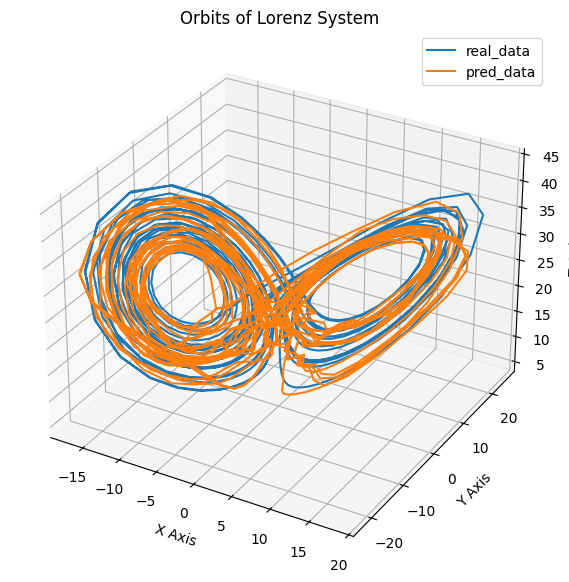

In [8]:
plot_lorenz(y_test1, y_pred1)